# Section 6 — Textual sentiment over time: three corpora

Thin driver notebook: all logic lives in `src/sentiment/`.

- **Regulators** (`scrape_regulators.py`): real, free PDFs — 11 Fed Financial Stability Reports (2020-2026) and 24 BIS Quarterly Reviews. IMF GFSR and ECB's historical FSR archive weren't resolved to scriptable URLs in the time available (see `docs/excluded_sources.md`).
- **Reddit** (`scrape_reddit.py`): fully implemented, needs the user's own `REDDIT_CLIENT_ID`/`REDDIT_CLIENT_SECRET`/`REDDIT_USER_AGENT` in the environment — not present this run.
- **Transcripts** (`scrape_transcripts.py`): stubbed — no shared structure across issuer IR sites to exploit (unlike BDC SOI's XBRL fragments).
- **Alarm index** (`analysis_alarm_index.py`): scored with VADER, not the Loughran-McDonald financial lexicon the mission brief specified — LM's download link is client-rendered and wasn't resolved to a scriptable URL this pass (see that module's docstring). A real bug was caught here by inspecting the actual text being scored, not just the chart: paragraph splitting on blank lines doesn't work for this PDF-extracted text (it merges glossaries/bylines/body into multi-page blobs), which silently drove every sentiment score toward 1.0 regardless of content — fixed by scoring a small sentence-window around each CLO mention instead.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.sentiment import (
    scrape_regulators, scrape_reddit, scrape_transcripts,
    analysis_alarm_index, analysis_narrative_arc, analysis_retail, analysis_insider_tone,
    viz_alarm, viz_narrative, viz_retail, viz_tone,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_regulators.run()
    scrape_reddit.run()
    scrape_transcripts.run()

## Analysis (interim -> final)

In [3]:
alarm = analysis_alarm_index.run()
narrative = analysis_narrative_arc.run()
retail = analysis_retail.run()
insider = analysis_insider_tone.run()

LM lexicon unavailable (LM master dictionary not found at /Users/zinuoshi/clo-atlas/data/_lexicons/lm_master_dictionary.csv. Run `python -m src.common.text --fetch-lexicon` (or the relevant scraper) to download it from https://sraf.nd.edu/loughranmcdonald-master-dictionary/ first; the resolved file URL gets logged to docs/sources.md on first fetch.); scoring with VADER only. Place the CSV at /Users/zinuoshi/clo-atlas/data/_lexicons/lm_master_dictionary.csv to also get LM scores.


no Reddit data cached (needs REDDIT_* env vars — see scrape_reddit.py); mention_volume_weekly is empty


scrape_transcripts.py is stubbed — no shared structure across issuer IR sites to exploit (unlike BDC SOI's XBRL fragments); would need one parser per company. See module docstring.


no transcript data available; tone_divergence is empty (see scrape_transcripts.py docstring)


## Viz (final -> figures/)

no Reddit data available (needs REDDIT_* env vars — see docs/excluded_sources.md); skipping viz_reddit_mentions_vs_etf_aum


no transcript tone data available (see docs/excluded_sources.md); skipping viz_tone_divergence


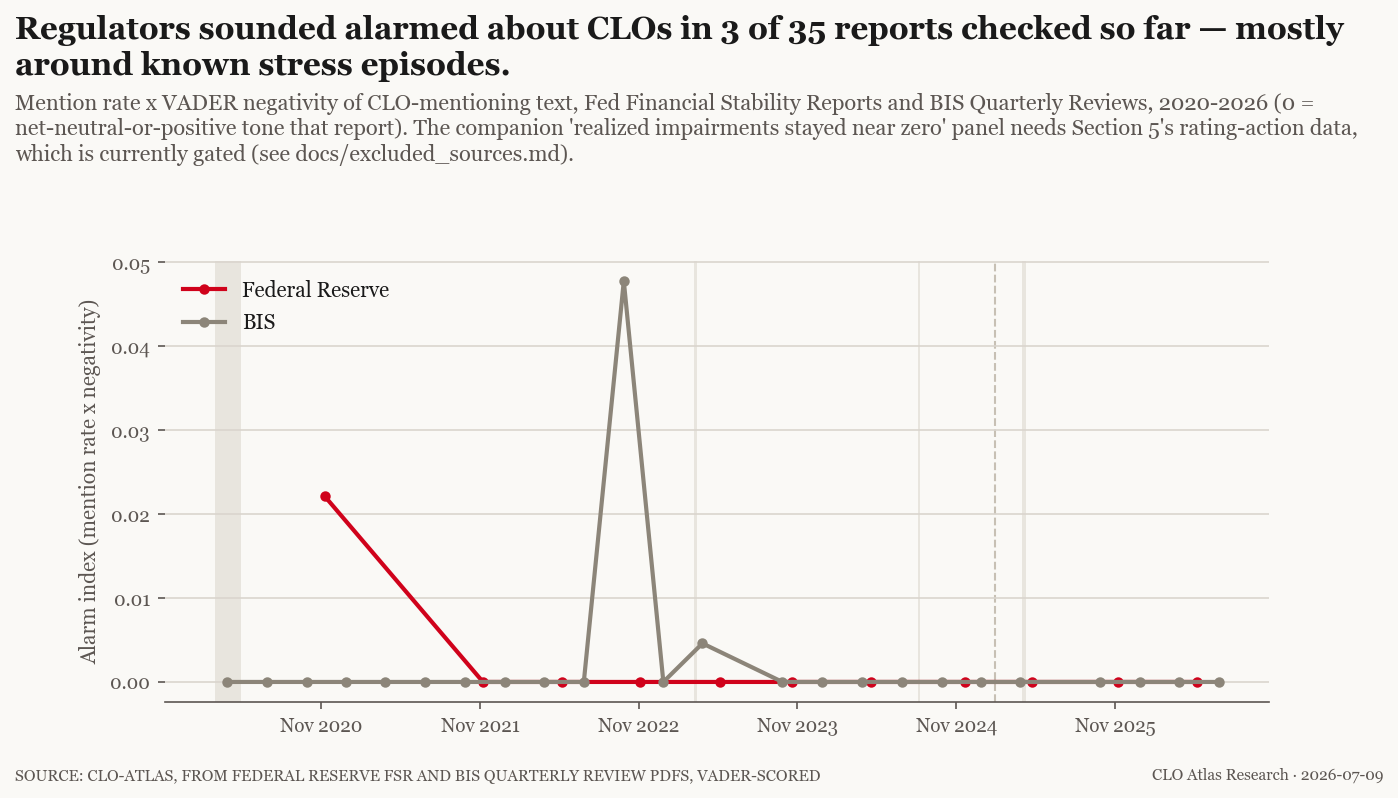

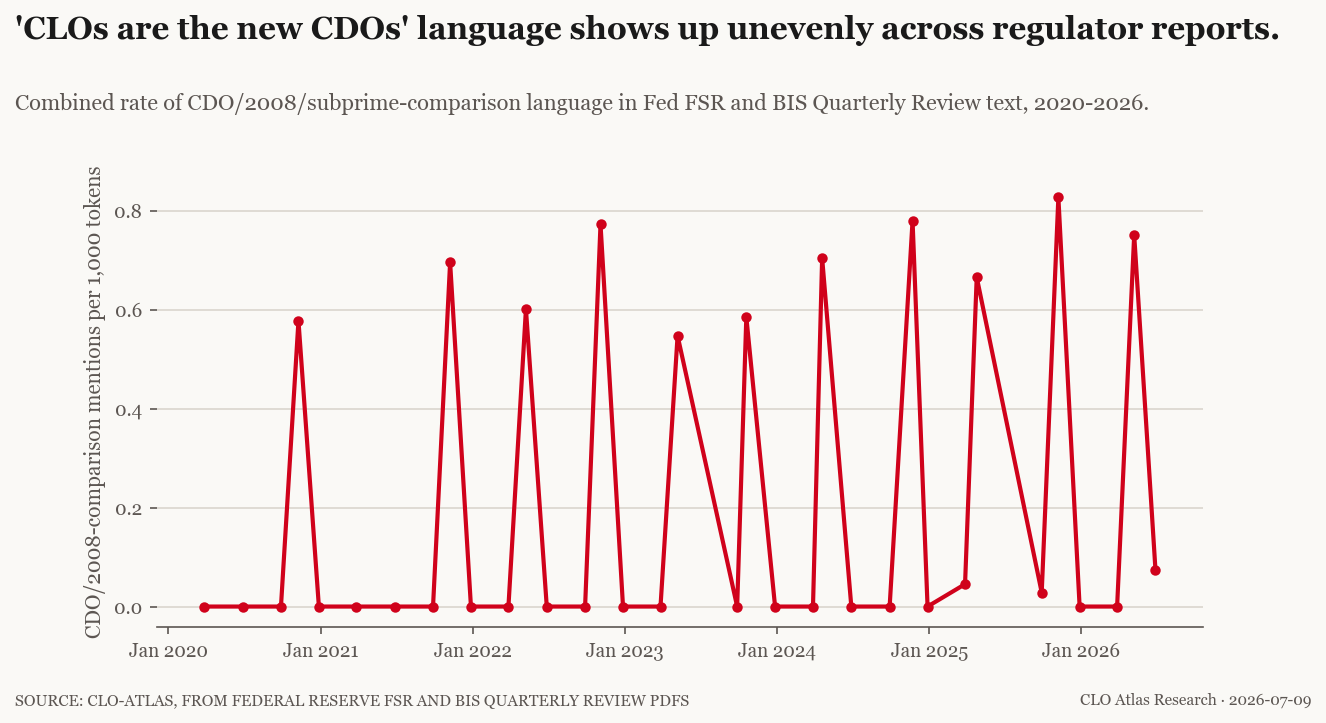

In [4]:
viz_alarm.run()
viz_narrative.run()
viz_retail.run()
viz_tone.run()

## Exhibits

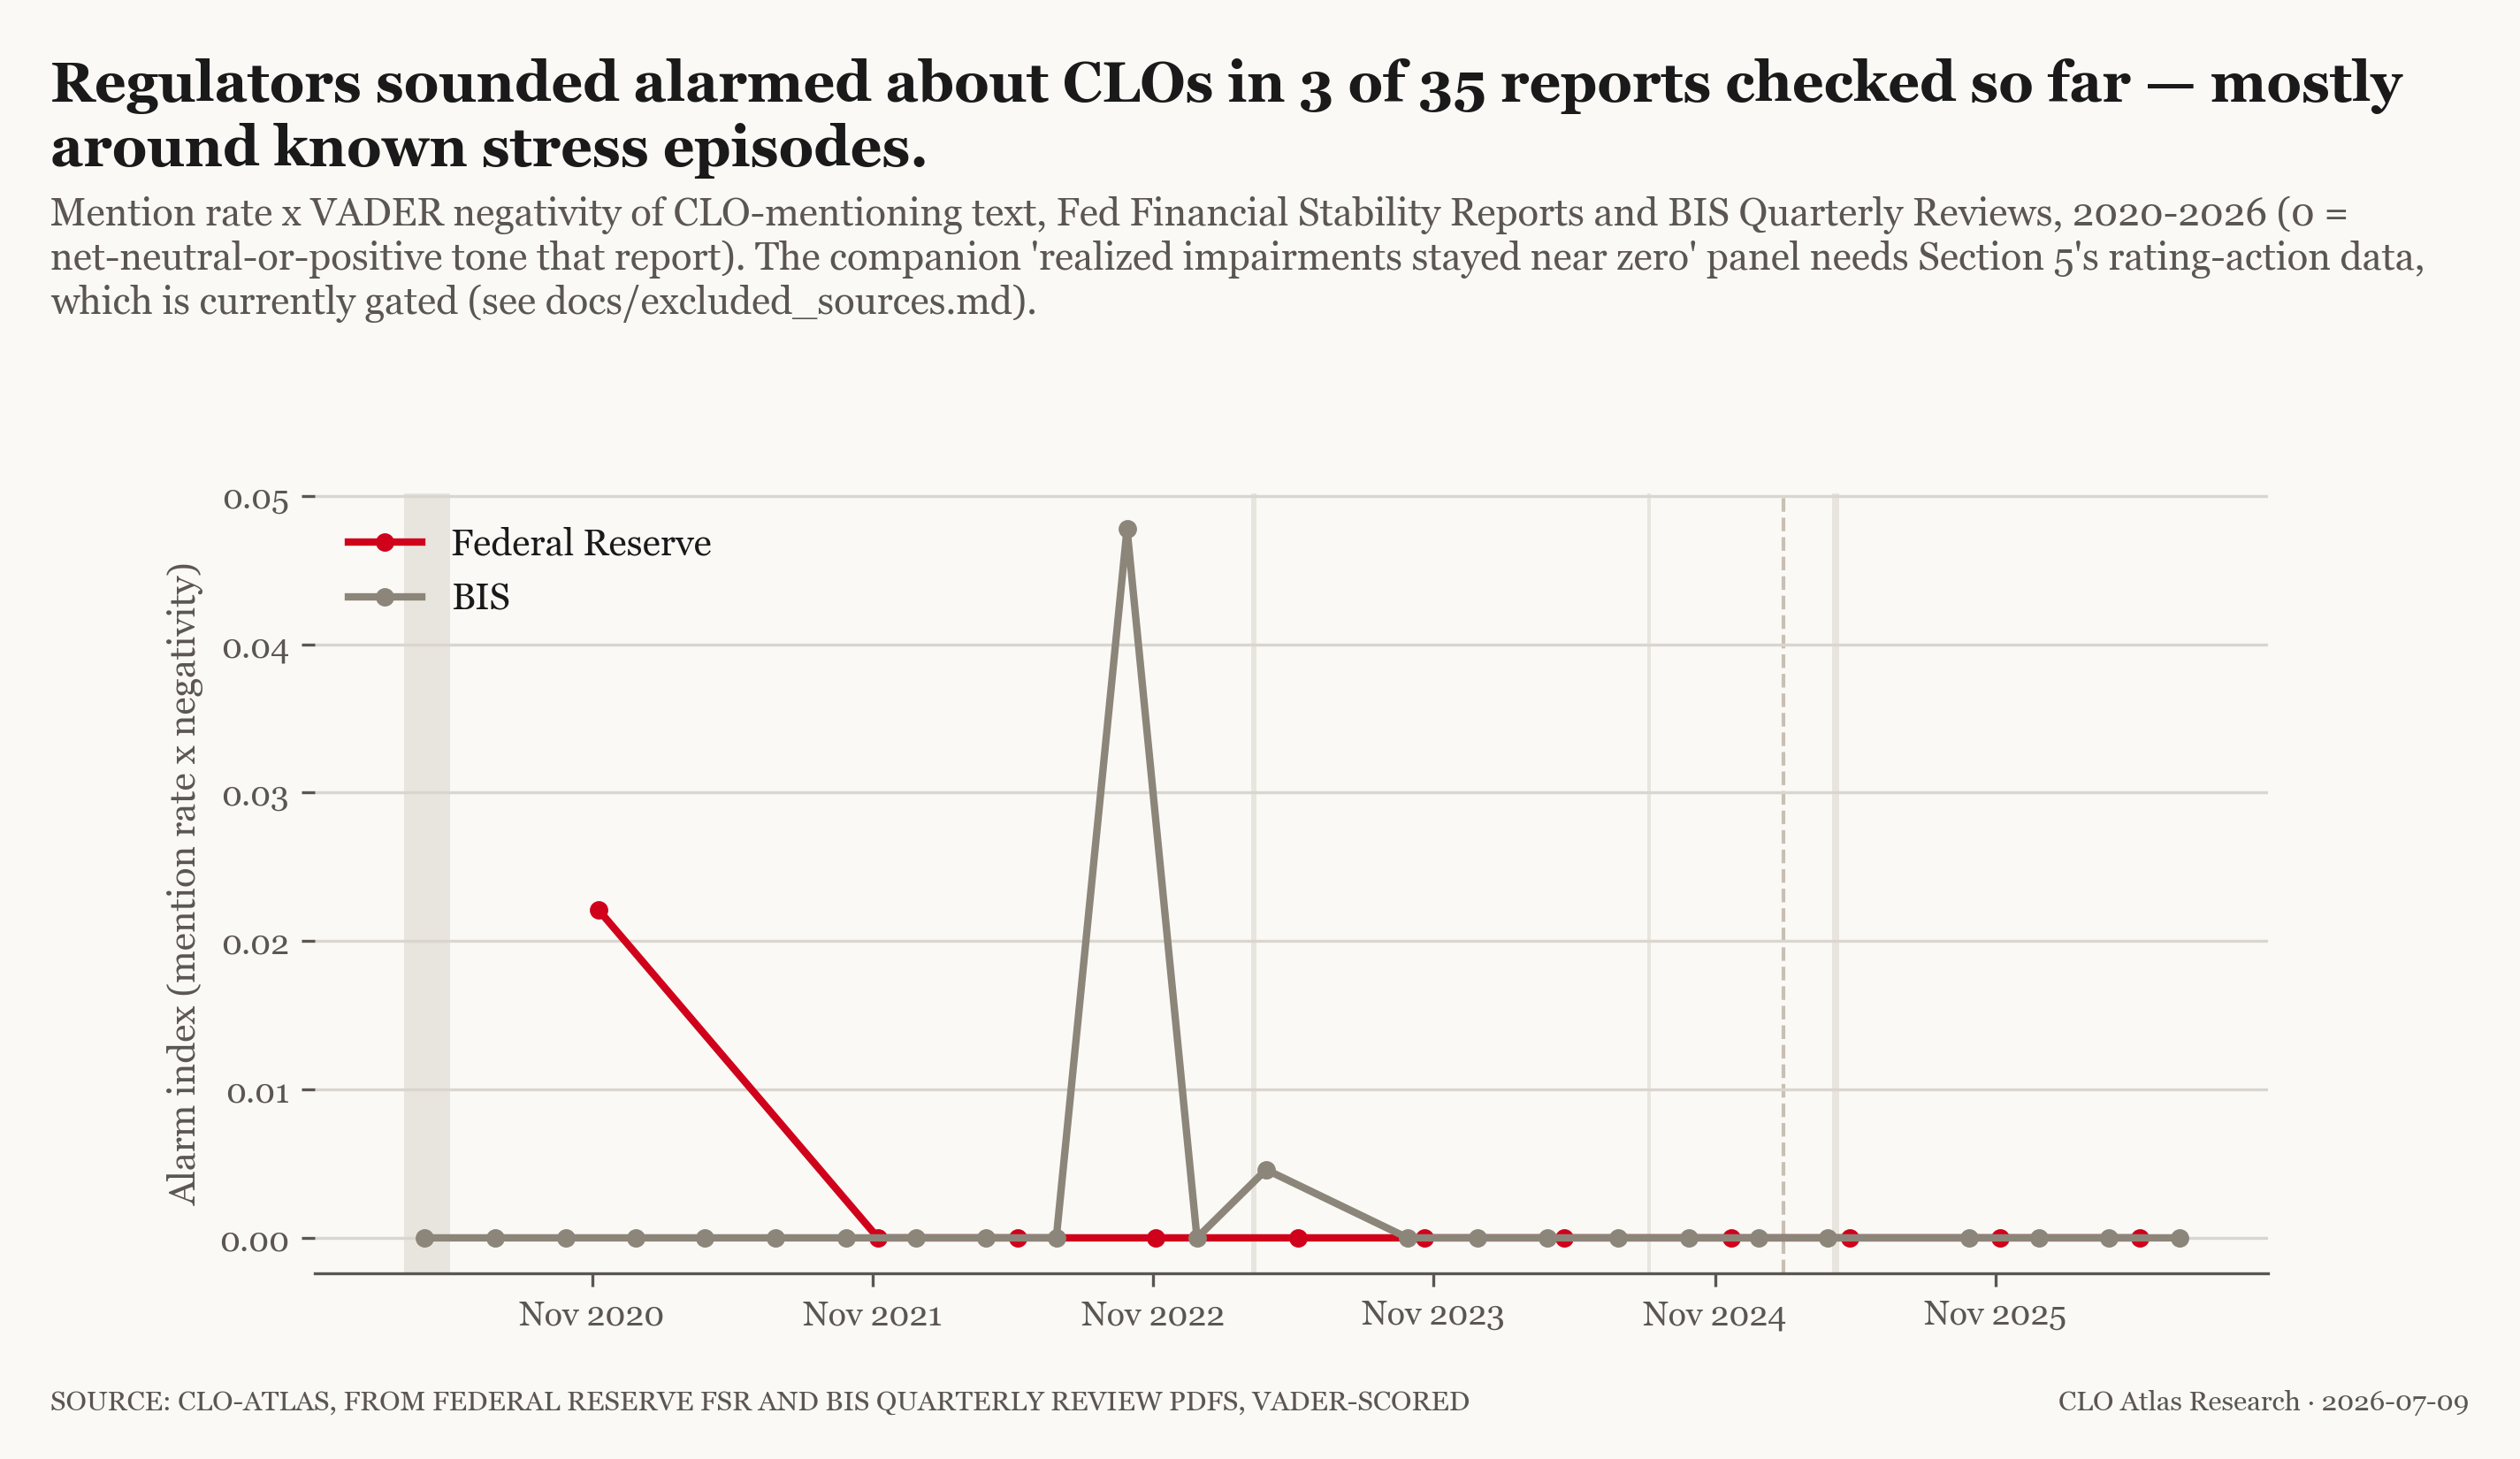

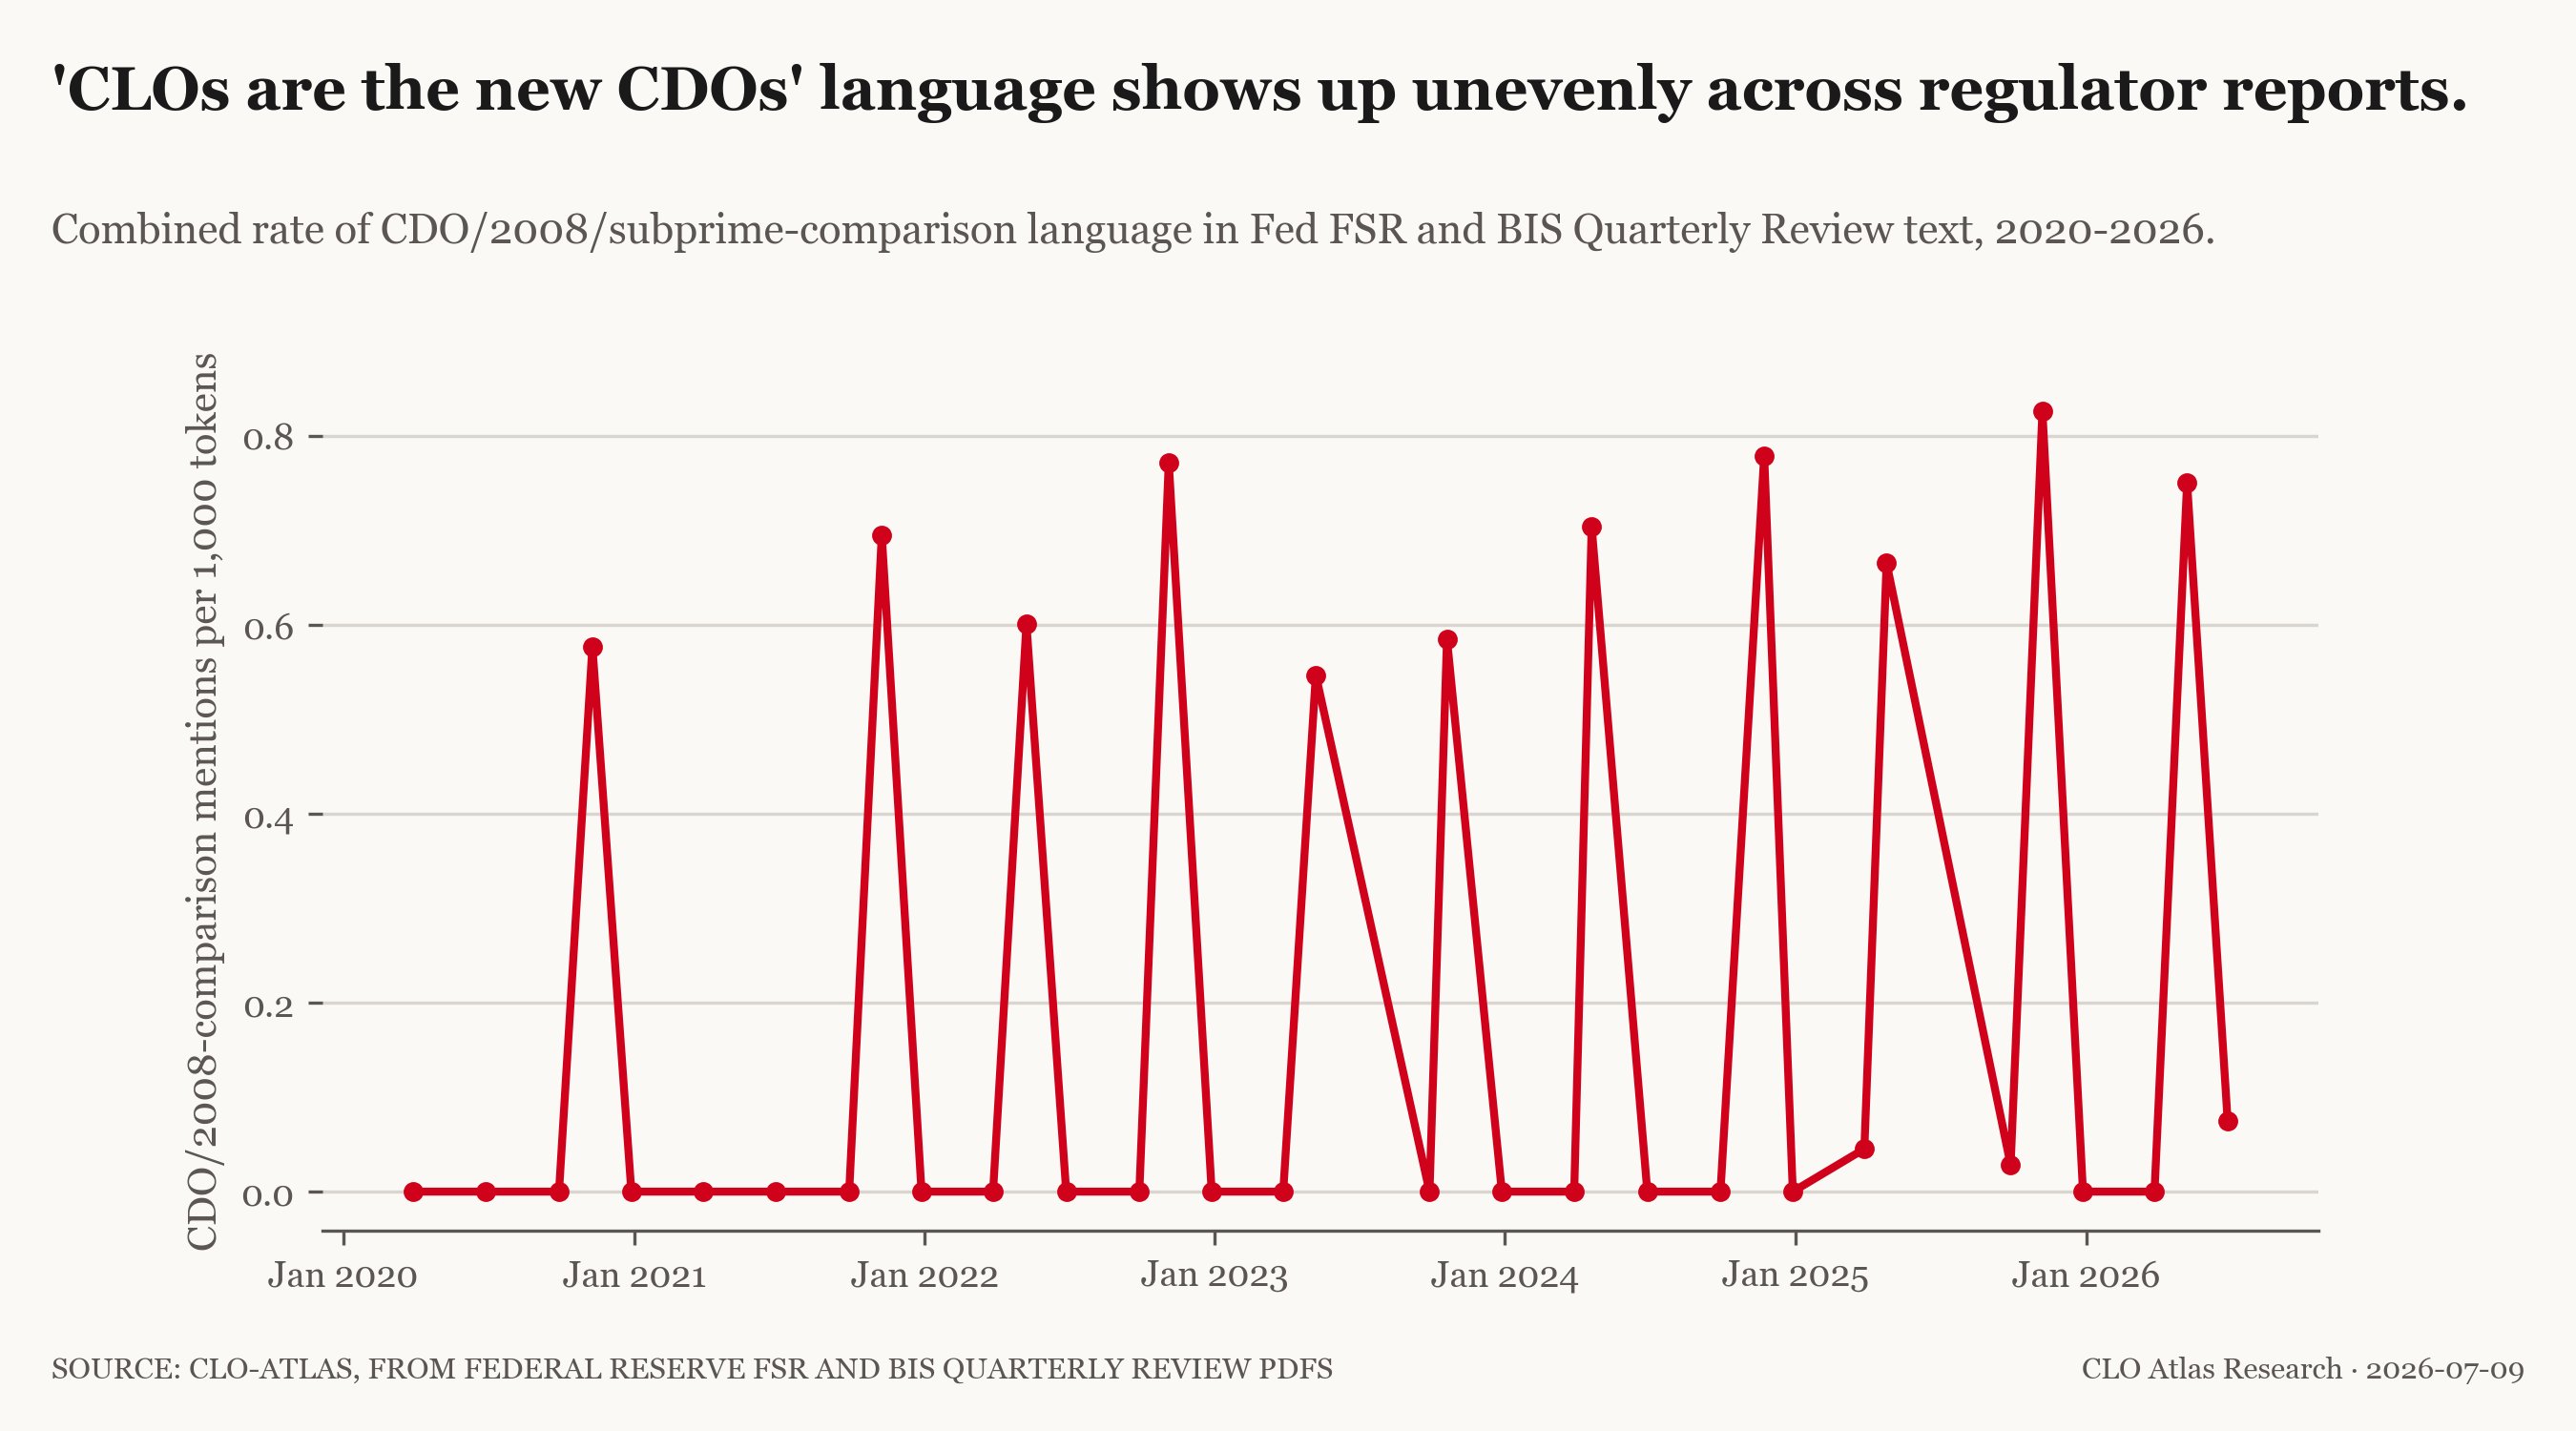

In [5]:
for name in ["viz_alarm_index_over_time", "viz_cdo_comparison_frequency"]:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")